In [1]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean as cmo
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import xenso
import xesmf as xe

plt.rcParams["font.family"] = "monospace"

In [2]:
def compute_coa_index(sst_anom, precip_anom):
    trop_mean_sst_anom = sst_anom.sel(lat=slice(-30, 30)).mean(dim=["lat", "lon"])
    ts_anom_adj = sst_anom - trop_mean_sst_anom

    en12 = xenso.indices.enzones(ts_anom_adj, zone="12")
    en12_fma = en12.resample(time="QS-FEB").mean()
    en12_fma = en12_fma.sel(time=en12_fma.time.dt.month.isin([2]))
    en12_fma_std = en12_fma.std("time")
    en12_fma_stdzed = (en12_fma - en12_fma.mean("time")) / en12_fma_std

    en34 = xenso.indices.enzones(ts_anom_adj, zone="34")
    en34_fma = en34.resample(time="QS-FEB").mean()
    en34_fma = en34_fma.sel(time=en34_fma.time.dt.month.isin([2]))
    en34_fma_std = en34_fma.std("time")
    en34_fma_stdzed = (en34_fma - en34_fma.mean("time")) / en34_fma_std

    # precipitation
    precip_anom = precip_anom * 86400
    en12_pr = xenso.indices.enzones(precip_anom, zone="12")
    en12_pr_fma = en12_pr.resample(time="QS-FEB").mean()
    en12_pr_fma = en12_pr_fma.sel(time=en12_pr_fma.time.dt.month.isin([2]))
    en12_pr_fma_std = en12_pr_fma.std("time")
    en12_pr_fma_stdzed = (en12_pr_fma - en12_pr_fma.mean("time")) / en12_pr_fma_std

    coa_events_strong = (
        (en12_fma_stdzed >= 0.8) & (en12_pr_fma_stdzed >= 0.8) & (en34_fma_stdzed < 0.5)
    )
    coa_events_strong["time"] = (
        coa_events_strong.indexes["time"].to_series().apply(lambda x: x.replace(day=15))
    )

    # compute standalone and followed by basin scale
    en34["time"] = (
        en34.indexes["time"]
        .to_series()
        .apply(lambda x: x.replace(day=15, hour=0, minute=0, second=0))
    )
    test = xr.full_like(en34, np.nan)
    # offset times by one month so we don't select the same month identified as coastal event. we are interested in the development in the following months.
    # offset is 3 because the events indentified have a coordinate that start on February (month 2) but represent the FMA season (months 2,3,4)
    _sel_time = coa_events_strong[coa_events_strong].time
    _sel_time["time"] = (
        _sel_time.indexes["time"]
        .to_series()
        .apply(lambda x: x + pd.DateOffset(months=3))
    )
    # fill the array with 1 for the selected times and fill nan forward so we have the following 6 months selected
    _sel_time = _sel_time.sel(time=slice(test.time.min(), test.time.max()))
    test.loc[{"time": _sel_time.time}] = 1
    test = test.ffill("time", 5)
    new_mask = test.dropna("time").astype(bool)
    if len(new_mask) == 0:
        standalone_coa = xr.DataArray(False)
        nonstandalone_coa = xr.DataArray(False)
    else:
        # get the mean en34 value for the next months so we can test if we had a basin-scale development
        en34_mask_mean = en34.sel(time=new_mask.time).groupby("time.year").mean()
        # print(en34.sel(time=new_mask.time))

        standalone_coa = en34_mask_mean < 0.5
        nonstandalone_coa = en34_mask_mean > 0.5

    return coa_events_strong, standalone_coa, nonstandalone_coa

In [3]:
target_rect_grid = xe.util.grid_global(0.5, 0.5, lon1=360)
target_rect_grid

<xarray.Dataset> Size: 8MB
Dimensions:  (y: 360, x: 720, y_b: 361, x_b: 721)
Coordinates:
    lon      (y, x) float64 2MB 0.25 0.75 1.25 1.75 ... 358.2 358.8 359.2 359.8
    lat      (y, x) float64 2MB -89.75 -89.75 -89.75 ... 89.75 89.75 89.75
    lon_b    (y_b, x_b) float64 2MB 0.0 0.5 1.0 1.5 ... 358.5 359.0 359.5 360.0
    lat_b    (y_b, x_b) float64 2MB -90.0 -90.0 -90.0 -90.0 ... 90.0 90.0 90.0
Dimensions without coordinates: y, x, y_b, x_b
Data variables:
    *empty*

# Load OBS

In [4]:
clim_slice = slice("1991", "2020")
ersstv5 = xr.open_dataset("../data/ersst.v5.nc").sst.sortby(
    "lat"
)
ersstv5_clim = ersstv5.sel(time=clim_slice).groupby("time.month").mean("time")
ersstv5_anom = ersstv5.groupby("time.month") - ersstv5_clim


hadisst = (
    xr.open_dataset("../data/HadISST_sst.nc")
    .sst.rename(latitude="lat", longitude="lon")
    .sortby("lat")
)
hadisst["lon"] = np.where(hadisst.lon < 0, hadisst.lon + 360, hadisst.lon)
hadisst = hadisst.sortby("lon").where(hadisst > -50)


hadisst_clim = hadisst.sel(time=clim_slice).groupby("time.month").mean("time")
hadisst_anom = hadisst.groupby("time.month") - hadisst_clim


era5_precip = (
    (
        xr.open_dataset(
            "../data/ERA5_total_precip_rate.nc"
        ).avg_tprate
    )
    .rename(valid_time="time", latitude="lat", longitude="lon")
    .sortby("lat")
)
era5_precip_clim = era5_precip.sel(time=clim_slice).groupby("time.month").mean("time")
era5_precip_anom = era5_precip.groupby("time.month") - era5_precip_clim

era5_wind_stress = (
    xr.open_dataset("../data/ERA5_wind_stress.nc")
    .rename(valid_time="time", latitude="lat", longitude="lon")
    .sortby("lat")
    .rename_vars(avg_iews="taux", avg_inss="tauy")
)
era5_wind_stress_clim = (
    era5_wind_stress.sel(time=clim_slice).groupby("time.month").mean("time")
)
era5_wind_stress_anom = era5_wind_stress.groupby("time.month") - era5_wind_stress_clim

pr20c = xr.open_dataset("../data/prate.mon.mean.nc").prate
pr20c_clim = pr20c.sel(time=clim_slice).groupby("time.month").mean("time")
pr20c_anom = pr20c.groupby("time.month") - pr20c_clim

In [5]:
(
    ersstv5_coa_index,
    ersstv5_coa_standalone,
    ersstv5_coa_nonstandalone,
) = compute_coa_index(ersstv5_anom, pr20c_anom)
(
    hadisst_coa_index,
    hadisst_coa_standalone,
    hadisst_coa_nonstandalone,
) = compute_coa_index(hadisst_anom, era5_precip_anom)

In [6]:
print(
    f"ERSSTv5: {ersstv5_coa_index.sum().values} events, {ersstv5_coa_standalone.sum().values} standalone, {ersstv5_coa_nonstandalone.sum().values} nonstandalone"
)
print(
    f"HADISST: {hadisst_coa_index.sum().values} events, {hadisst_coa_standalone.sum().values} standalone, {hadisst_coa_nonstandalone.sum().values} nonstandalone"
)

ERSSTv5: 5 events, 3 standalone, 2 nonstandalone
HADISST: 4 events, 1 standalone, 3 nonstandalone


In [7]:
print(
    "ERSSTv5 COA Event Years:", ersstv5_coa_index[ersstv5_coa_index].time.dt.year.data
)
print(
    "Standalone Event Years:", ersstv5_coa_standalone[ersstv5_coa_standalone].year.data
)
print(
    "Non-Standalone Event Years:",
    ersstv5_coa_nonstandalone[ersstv5_coa_nonstandalone].year.data,
)

print(
    "\nHADISST COA Event Years:", hadisst_coa_index[hadisst_coa_index].time.dt.year.data
)
print(
    "Standalone Event Years:", hadisst_coa_standalone[hadisst_coa_standalone].year.data
)
print(
    "Non-Standalone Event Years:",
    hadisst_coa_nonstandalone[hadisst_coa_nonstandalone].year.data,
)

ERSSTv5 COA Event Years: [1932 1939 1965 1972 2012]
Standalone Event Years: [1932 1939 2012]
Non-Standalone Event Years: [1965 1972]

HADISST COA Event Years: [1957 1972 2017 2023]
Standalone Event Years: [2017]
Non-Standalone Event Years: [1957 1972 2023]


# Regrid and composite

In [8]:
def regrid_data(data, target_grid):
    regridder = xe.Regridder(
        data.isel(time=0, drop=True),
        target_rect_grid,
        "conservative",
        periodic=True,
        ignore_degenerate=True,
    )
    regrid_data = regridder(data)
    regrid_data["y"] = regrid_data.lat[:, 0].data
    regrid_data["x"] = regrid_data.lon[0, :].data
    regrid_data = (
        regrid_data.drop_vars(["lat", "lon"]).rename(y="lat", x="lon").sortby("lat")
    )
    return regrid_data

# Combined

In [9]:
hadisst_anom = regrid_data(hadisst_anom, target_rect_grid)
ersstv5_anom = regrid_data(ersstv5_anom, target_rect_grid)

# HadISST composites SST
hadisst_composite = hadisst_anom.sel(
    time=(
        hadisst_anom.time.dt.year.isin(
            [hadisst_coa_index[hadisst_coa_index].time.dt.year.data]
        )
        & hadisst_anom.time.dt.month.isin([2, 3, 4])
    )
)
hadisst_composite = hadisst_composite - hadisst_composite.sel(lat=slice(-30, 30)).mean(
    dim=["lat", "lon"]
)

ersstv5_composite = ersstv5_anom.sel(
    time=(
        ersstv5_anom.time.dt.year.isin(
            [ersstv5_coa_index[ersstv5_coa_index].time.dt.year.data]
        )
        & ersstv5_anom.time.dt.month.isin([2, 3, 4])
    )
)
ersstv5_composite = ersstv5_composite - ersstv5_composite.sel(lat=slice(-30, 30)).mean(
    dim=["lat", "lon"]
)

sst_composite = xr.concat([hadisst_composite, ersstv5_composite], dim="time")
sst_composite_mean = sst_composite.mean(dim="time")

## Precipitation composites

pr20c_anom = regrid_data(pr20c_anom, target_rect_grid)
era5_precip_anom = regrid_data(era5_precip_anom, target_rect_grid)

era5_precip_composite = (
    era5_precip_anom.sel(
        time=(
            era5_precip_anom.time.dt.year.isin(
                [hadisst_coa_index[hadisst_coa_index].time.dt.year.data]
            )
            & era5_precip_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)

pr20c_composite = (
    pr20c_anom.sel(
        time=(
            pr20c_anom.time.dt.year.isin(
                [ersstv5_coa_index[ersstv5_coa_index].time.dt.year.data]
            )
            & pr20c_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)

pr_composite = xr.concat(
    [era5_precip_composite.drop_vars(["number", "expver"]), pr20c_composite],
    dim="time",
    join="outer",
)
pr_composite_mean = pr_composite.mean(dim="time")


# Wind Stress composites

era5_wind_stress_anom = regrid_data(era5_wind_stress_anom, target_rect_grid)
taux_composite = era5_wind_stress_anom.taux.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_index[hadisst_coa_index].time.dt.year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")
tauy_composite = era5_wind_stress_anom.tauy.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_index[hadisst_coa_index].time.dt.year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")

/glade/work/griverat/conda-envs/workenv/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/griverat/conda-envs/workenv/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')
/glade/work/griverat/conda-envs/workenv/lib/python3.12/site-packages/xesmf/backend.py:56: UserWarning: Latitude is outside of [-90, 90]
  warnings.warn('Latitude is outside of [-90, 90]')


## Standalone

In [10]:
hadisst_composite_standalone = hadisst_anom.sel(
    time=(
        hadisst_anom.time.dt.year.isin(
            [hadisst_coa_standalone[hadisst_coa_standalone].year.data]
        )
        & hadisst_anom.time.dt.month.isin([2, 3, 4])
    )
)
hadisst_composite_standalone = (
    hadisst_composite_standalone
    - hadisst_composite_standalone.sel(lat=slice(-30, 30)).mean(dim=["lat", "lon"])
)
ersstv5_composite_standalone = ersstv5_anom.sel(
    time=(
        ersstv5_anom.time.dt.year.isin(
            [ersstv5_coa_standalone[ersstv5_coa_standalone].year.data]
        )
        & ersstv5_anom.time.dt.month.isin([2, 3, 4])
    )
)
ersstv5_composite_standalone = (
    ersstv5_composite_standalone
    - ersstv5_composite_standalone.sel(lat=slice(-30, 30)).mean(dim=["lat", "lon"])
)
sst_composite_standalone = xr.concat(
    [hadisst_composite_standalone, ersstv5_composite_standalone], dim="time"
)
sst_composite_standalone_mean = sst_composite_standalone.mean(dim="time")

era5_precip_composite_standalone = (
    era5_precip_anom.sel(
        time=(
            era5_precip_anom.time.dt.year.isin(
                [hadisst_coa_standalone[hadisst_coa_standalone].year.data]
            )
            & era5_precip_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)

pr20c_composite_standalone = (
    pr20c_anom.sel(
        time=(
            pr20c_anom.time.dt.year.isin(
                [ersstv5_coa_standalone[ersstv5_coa_standalone].year.data]
            )
            & pr20c_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)
pr_composite_standalone = xr.concat(
    [
        era5_precip_composite_standalone.drop_vars(["number", "expver"]),
        pr20c_composite_standalone,
    ],
    dim="time",
    join="outer",
)
pr_composite_standalone_mean = pr_composite_standalone.mean(dim="time")

taux_composite_standalone = era5_wind_stress_anom.taux.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_standalone[hadisst_coa_standalone].year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")

tauy_composite_standalone = era5_wind_stress_anom.tauy.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_standalone[hadisst_coa_standalone].year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")

## Non-Standalone

In [11]:
hadisst_composite_nonstandalone = hadisst_anom.sel(
    time=(
        hadisst_anom.time.dt.year.isin(
            [hadisst_coa_nonstandalone[hadisst_coa_nonstandalone].year.data]
        )
        & hadisst_anom.time.dt.month.isin([2, 3, 4])
    )
)
hadisst_composite_nonstandalone = (
    hadisst_composite_nonstandalone
    - hadisst_composite_nonstandalone.sel(lat=slice(-30, 30)).mean(dim=["lat", "lon"])
)
ersstv5_composite_nonstandalone = ersstv5_anom.sel(
    time=(
        ersstv5_anom.time.dt.year.isin(
            [ersstv5_coa_nonstandalone[ersstv5_coa_nonstandalone].year.data]
        )
        & ersstv5_anom.time.dt.month.isin([2, 3, 4])
    )
)
ersstv5_composite_nonstandalone = (
    ersstv5_composite_nonstandalone
    - ersstv5_composite_nonstandalone.sel(lat=slice(-30, 30)).mean(dim=["lat", "lon"])
)
sst_composite_nonstandalone = xr.concat(
    [hadisst_composite_nonstandalone, ersstv5_composite_nonstandalone], dim="time"
)
sst_composite_nonstandalone_mean = sst_composite_nonstandalone.mean(dim="time")

era5_precip_composite_nonstandalone = (
    era5_precip_anom.sel(
        time=(
            era5_precip_anom.time.dt.year.isin(
                [hadisst_coa_nonstandalone[hadisst_coa_nonstandalone].year.data]
            )
            & era5_precip_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)
pr20c_composite_nonstandalone = (
    pr20c_anom.sel(
        time=(
            pr20c_anom.time.dt.year.isin(
                [ersstv5_coa_nonstandalone[ersstv5_coa_nonstandalone].year.data]
            )
            & pr20c_anom.time.dt.month.isin([2, 3, 4])
        )
    )
    * 86400
)
pr_composite_nonstandalone = xr.concat(
    [
        era5_precip_composite_nonstandalone.drop_vars(["number", "expver"]),
        pr20c_composite_nonstandalone,
    ],
    dim="time",
    join="outer",
)
pr_composite_nonstandalone_mean = pr_composite_nonstandalone.mean(dim="time")


taux_composite_nonstandalone = era5_wind_stress_anom.taux.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_nonstandalone[hadisst_coa_nonstandalone].year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")

tauy_composite_nonstandalone = era5_wind_stress_anom.tauy.sel(
    time=(
        era5_wind_stress_anom.time.dt.year.isin(
            [hadisst_coa_nonstandalone[hadisst_coa_nonstandalone].year.data]
        )
        & era5_wind_stress_anom.time.dt.month.isin([2, 3, 4])
    )
).mean("time")

# GCMs data

In [12]:
green_coa_composite = xr.open_dataset(
    "../data/green_coa_composite.nc"
)
green_coa_standalone_composite = xr.open_dataset(
    "../data/green_coa_standalone_composite.nc"
)
green_coa_nonstandalone_composite = xr.open_dataset(
    "../data/green_coa_nonstandalone_composite.nc"
)

orange_coa_composite = xr.open_dataset(
    "../data/orange_coa_composite.nc"
)
orange_coa_standalone_composite = xr.open_dataset(
    "../data/orange_coa_standalone_composite.nc"
)
orange_coa_nonstandalone_composite = xr.open_dataset(
    "../data/orange_coa_nonstandalone_composite.nc"
)

red_coa_composite = xr.open_dataset(
    "../data/red_coa_composite.nc"
)
red_coa_standalone_composite = xr.open_dataset(
    "../data/red_coa_standalone_composite.nc"
)
red_coa_nonstandalone_composite = xr.open_dataset(
    "../data/red_coa_nonstandalone_composite.nc"
)

combined_coa_composite = xr.concat(
    [orange_coa_composite, green_coa_composite, red_coa_composite], dim="time"
)
combined_coa_standalone_composite = xr.concat(
    [orange_coa_standalone_composite, green_coa_standalone_composite, red_coa_standalone_composite],
    dim="time",
)
combined_coa_nonstandalone_composite = xr.concat(
    [orange_coa_nonstandalone_composite, green_coa_nonstandalone_composite, red_coa_nonstandalone_composite],
    dim="time",
)

In [13]:
green_coa_composite_mean = green_coa_composite.mean(dim="time")
green_coa_standalone_composite_mean = green_coa_standalone_composite.mean(dim="time")
green_coa_nonstandalone_composite_mean = green_coa_nonstandalone_composite.mean(
    dim="time"
)

orange_coa_composite_mean = orange_coa_composite.mean(dim="time")
orange_coa_standalone_composite_mean = orange_coa_standalone_composite.mean(dim="time")
orange_coa_nonstandalone_composite_mean = orange_coa_nonstandalone_composite.mean(
    dim="time"
)

red_coa_composite_mean = red_coa_composite.mean(dim="time")
red_coa_standalone_composite_mean = red_coa_standalone_composite.mean(dim="time")
red_coa_nonstandalone_composite_mean = red_coa_nonstandalone_composite.mean(
    dim="time"
)

combined_coa_composite_mean = combined_coa_composite.mean(dim="time")
combined_coa_standalone_composite_mean = combined_coa_standalone_composite.mean(
    dim="time"
)
combined_coa_nonstandalone_composite_mean = combined_coa_nonstandalone_composite.mean(
    dim="time"
)

# Plotting

/glade/derecho/scratch/griverat/tmp/ipykernel_106741/2639878023.py:266: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


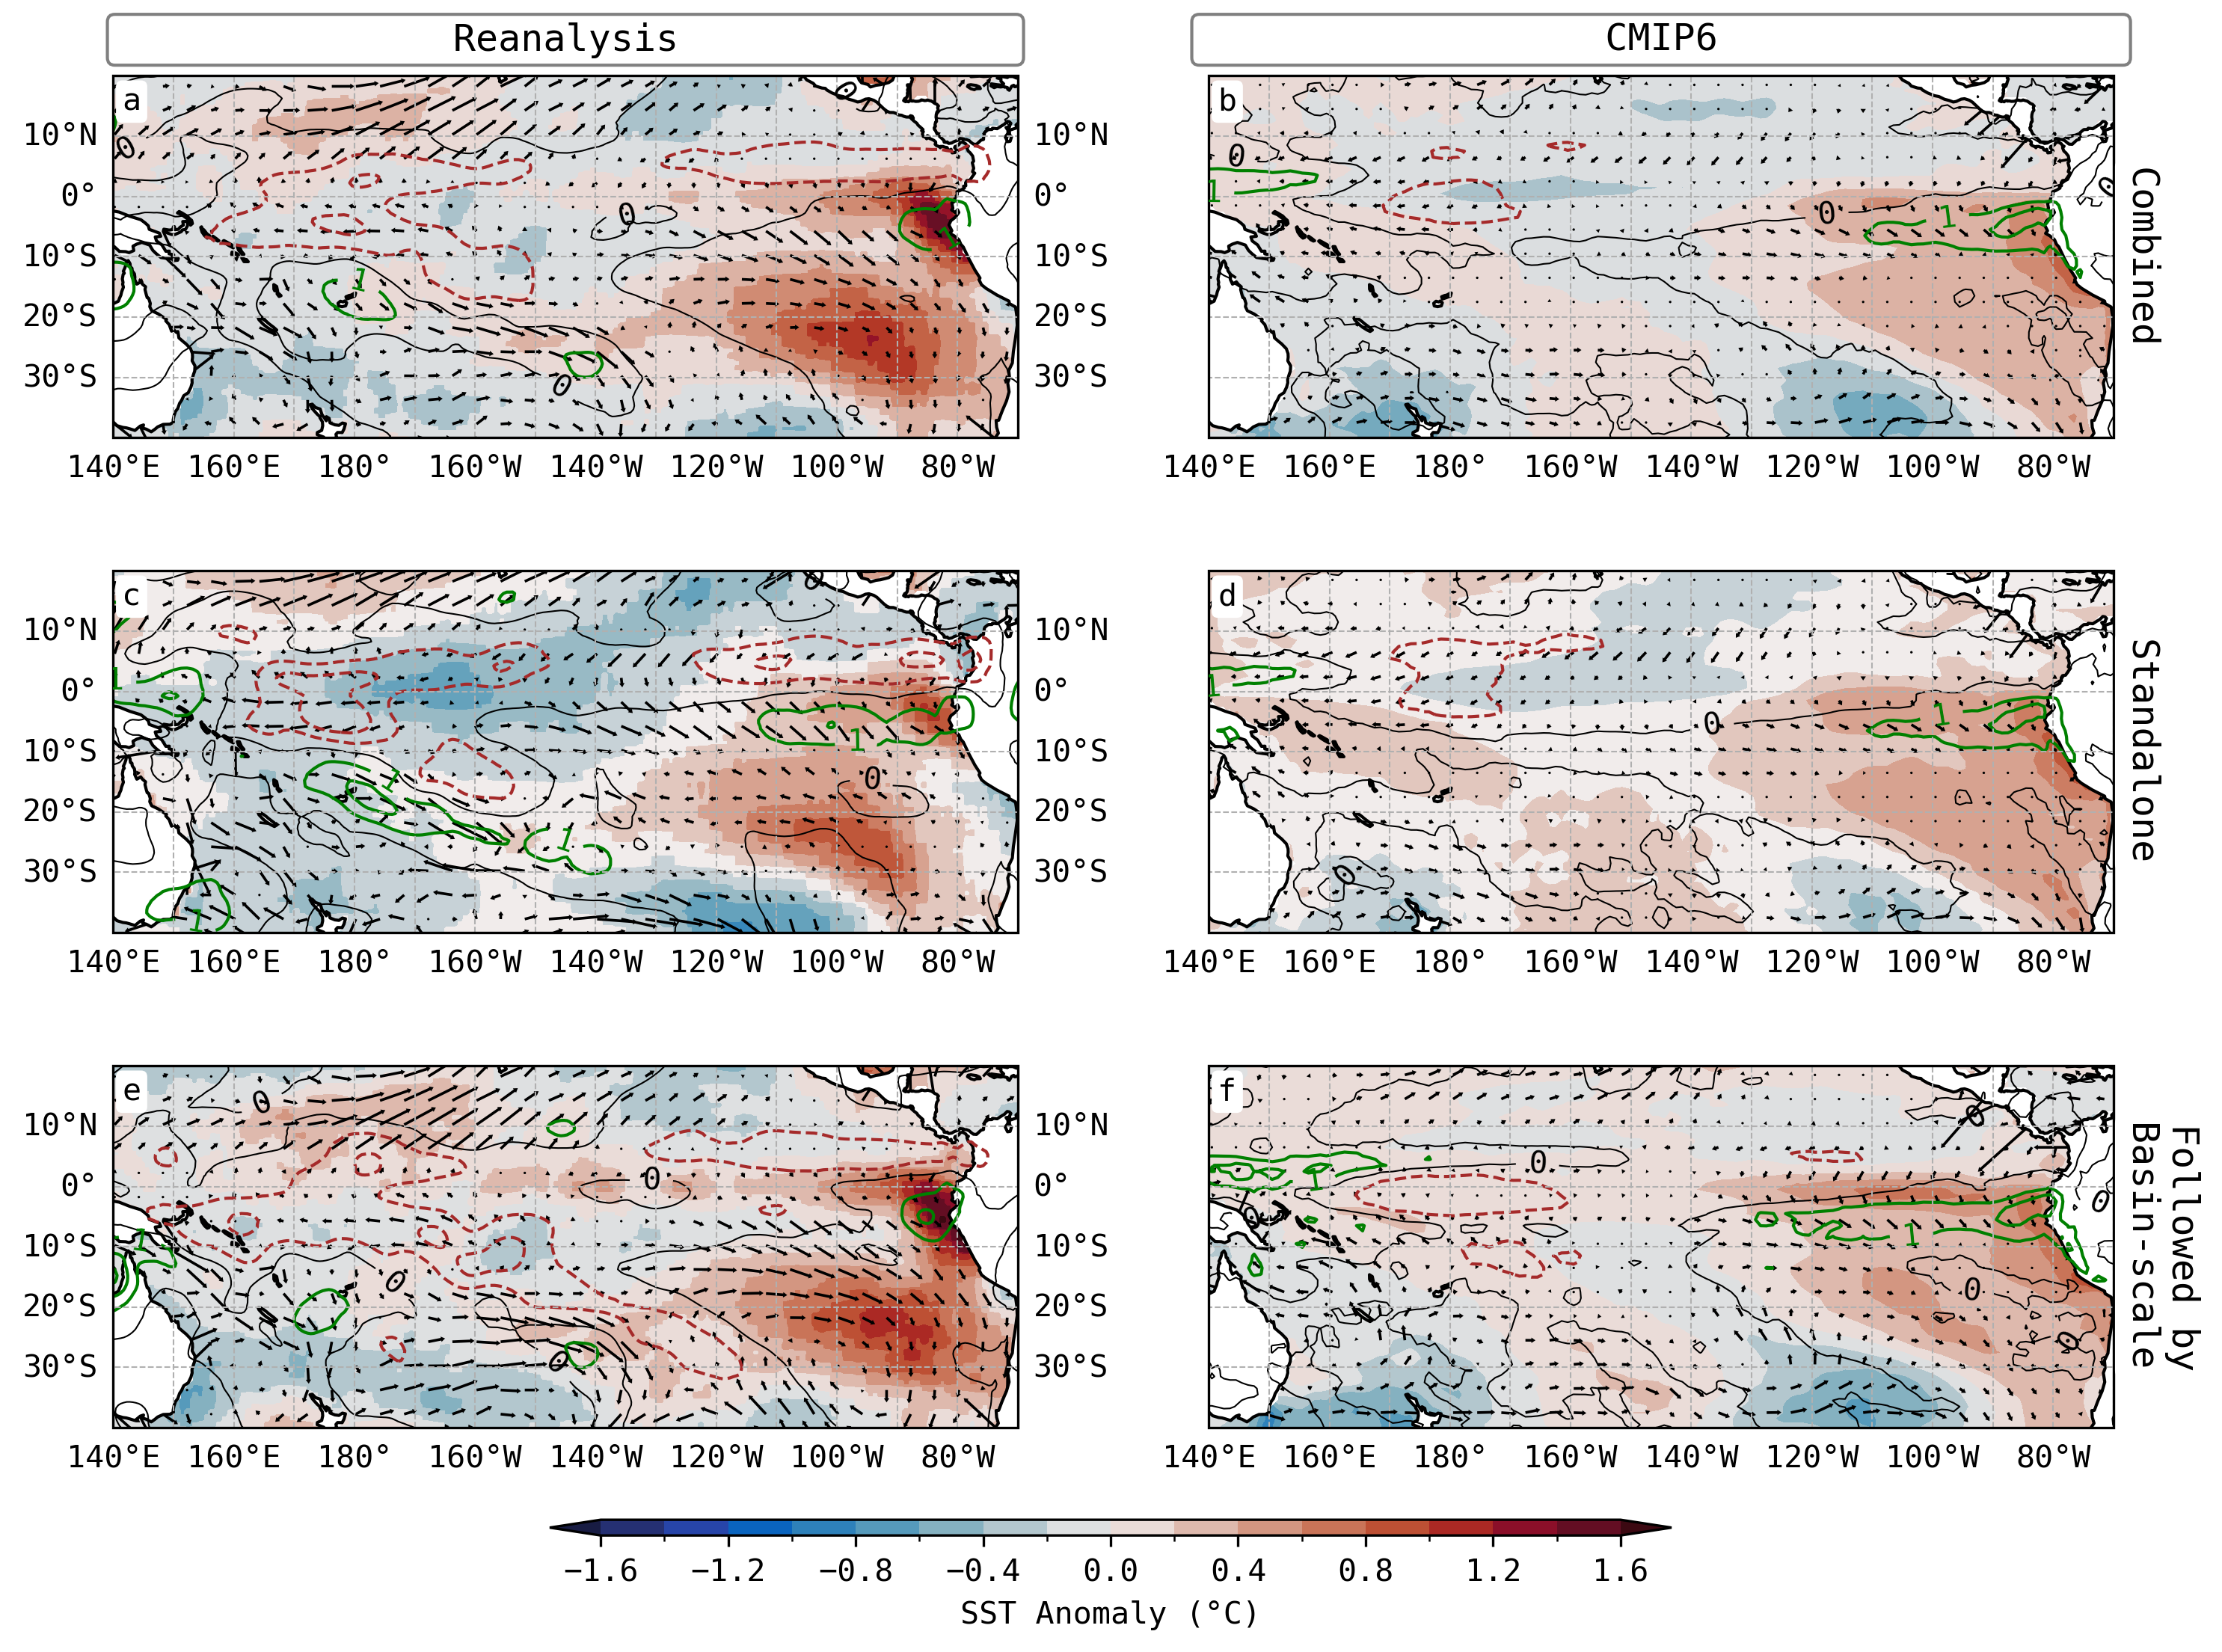

In [14]:
fig, axs = plt.subplots(
    figsize=(10, 7),
    nrows=3,
    ncols=2,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)),
    dpi=300,
)

_axs = axs[:, 0]

for num, (
    ax,
    sst_sel_plot,
    prec_sel_plot,
    u_sel_plot,
    v_sel_plot,
    letter,
    suptitle,
) in enumerate(
    zip(
        _axs,
        [
            sst_composite_mean,
            sst_composite_standalone_mean,
            sst_composite_nonstandalone_mean,
        ],
        [
            pr_composite_mean,
            pr_composite_standalone_mean,
            pr_composite_nonstandalone_mean,
        ],
        [
            taux_composite * 100,
            taux_composite_standalone * 100,
            taux_composite_nonstandalone * 100,
        ],
        [
            tauy_composite * 100,
            tauy_composite_standalone * 100,
            tauy_composite_nonstandalone * 100,
        ],
        ["a", "c", "e"],
        ["Combined", "Standalone", "Basin-scale"],
    )
):
    _lat = u_sel_plot.lat.data
    _lon = u_sel_plot.lon.data
    prec_sel_plot = prec_sel_plot.rolling(
        lat=10, lon=10, min_periods=1, center=True
    ).mean()
    sst_plot = sst_sel_plot.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmax=1.6,
        cmap=cmo.cm.balance,
        levels=17,
        add_colorbar=False,
    )

    conts = (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(0, 10, 1)[1:],
        colors="g",
        linewidths=1,
    )

    (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(-20, 0, 1),
        colors="brown",
        linewidths=1,
    )

    zero_cont = (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=[0],
        colors="k",
        linewidths=0.5,
    )

    nskip = 8
    q = ax.quiver(
        _lon[::nskip].data,
        _lat[::nskip].data,  # Reduce density for clarity
        u_sel_plot.where(u_sel_plot > -8)[::nskip, ::nskip].data,
        v_sel_plot.where(v_sel_plot > -8)[::nskip, ::nskip].data,
        transform=ccrs.PlateCarree(),
        scale=90,  # Adjust arrow size
        width=0.003,
        headlength=1.5,
        headaxislength=1.5,
        headwidth=2,
    )
    ax.clabel(conts, inline_spacing=-2, fmt="%1.0f")
    ax.clabel(zero_cont, inline_spacing=-2, fmt="%1.0f")

    gls = ax.gridlines(
        draw_labels=True, xlocs=np.arange(-180, 180, 10), ls="--", lw=0.5
    )
    gls.top_labels = False

    # ax.coastlines()
    ax.add_feature(cfeature.LAND, facecolor="white", zorder=1, edgecolor="k")
    ax.set_extent([140, 290, -40, 20], crs=ccrs.PlateCarree())
    # ax.set_title("March 2023")
    # ax.set_title(suptitle)
    if num == 0:
        ax.text(
            0.5,
            1.05,
            " " * 15 + "Reanalysis" + " " * 15,
            transform=ax.transAxes,
            va="bottom",
            ha="center",
            fontsize=12,
            bbox=dict(facecolor="white", edgecolor="grey", boxstyle="round,pad=0.2"),
        )
    ax.text(
        0.01,
        0.97,
        letter,
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
    )

_axs = axs[:, 1]
tau_factor = 100

first_var = green_coa_composite_mean
second_var = green_coa_standalone_composite_mean
third_var = green_coa_nonstandalone_composite_mean

for num, (
    ax,
    sst_sel_plot,
    prec_sel_plot,
    u_sel_plot,
    v_sel_plot,
    letter,
    suptitle,
) in enumerate(
    zip(
        _axs,
        [first_var.tos, second_var.tos, third_var.tos],
        [first_var.pr, second_var.pr, third_var.pr],
        [
            first_var.tauu * tau_factor,
            second_var.tauu * tau_factor,
            third_var.tauu * tau_factor,
        ],
        [
            first_var.tauv * tau_factor,
            second_var.tauv * tau_factor,
            third_var.tauv * tau_factor,
        ],
        ["b", "d", "f"],
        ["Combined", "Standalone", "Followed by\nBasin-scale"],
    )
):

    _lat = u_sel_plot.lat.data
    _lon = u_sel_plot.lon.data

    prec_sel_plot = prec_sel_plot * 86400
    sst_plot = sst_sel_plot.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmax=1.6,
        cmap=cmo.cm.balance,
        levels=17,
        add_colorbar=False,
    )

    conts = (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(0, 10, 1)[1:],
        colors="g",
        linewidths=1,
    )

    (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=np.arange(-20, 0, 1),
        colors="brown",
        linewidths=1,
    )

    zero_cont = (prec_sel_plot).plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=[0],
        colors="k",
        linewidths=0.5,
    )

    nskip = 4
    q = ax.quiver(
        _lon[::nskip].data,
        _lat[::nskip].data,  # Reduce density for clarity
        u_sel_plot.where(u_sel_plot > -8)[::nskip, ::nskip].data,
        v_sel_plot.where(v_sel_plot > -8)[::nskip, ::nskip].data,
        transform=ccrs.PlateCarree(),
        scale=50,  # Adjust arrow size
        width=0.003,
        headlength=1.5,
        headaxislength=1.5,
        headwidth=2,
    )

    ax.clabel(conts, inline_spacing=-2, fmt="%1.0f")
    ax.clabel(zero_cont, inline_spacing=-2, fmt="%1.0f")

    gls = ax.gridlines(
        draw_labels=True, xlocs=np.arange(-180, 180, 10), ls="--", lw=0.5
    )
    gls.top_labels = False
    gls.left_labels = False
    gls.right_labels = False

    ax.add_feature(cfeature.LAND, facecolor="white", zorder=1, edgecolor="k")
    ax.set_extent([140, 290, -40, 20], crs=ccrs.PlateCarree())
    if num == 0:
        ax.text(
            0.5,
            1.05,
            " " * 18 + "CMIP6" + " " * 18,
            transform=ax.transAxes,
            va="bottom",
            ha="center",
            fontsize=12,
            bbox=dict(facecolor="white", edgecolor="grey", boxstyle="round,pad=0.2"),
        )
    ax.text(
        1.01,
        0.5,
        suptitle,
        transform=ax.transAxes,
        va="center",
        ha="left",
        rotation=-90,
        fontsize=12,
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
    )
    ax.text(
        0.01,
        0.97,
        letter,
        transform=ax.transAxes,
        va="top",
        ha="left",
        bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
    )


cax = fig.add_axes([0.25, -0.001, 0.5, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(sst_plot, cax=cax, orientation="horizontal")
cbar.set_label("SST Anomaly (°C)")

fig.tight_layout()

# Supplementary Figure S1

/glade/derecho/scratch/griverat/tmp/ipykernel_106741/176707589.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


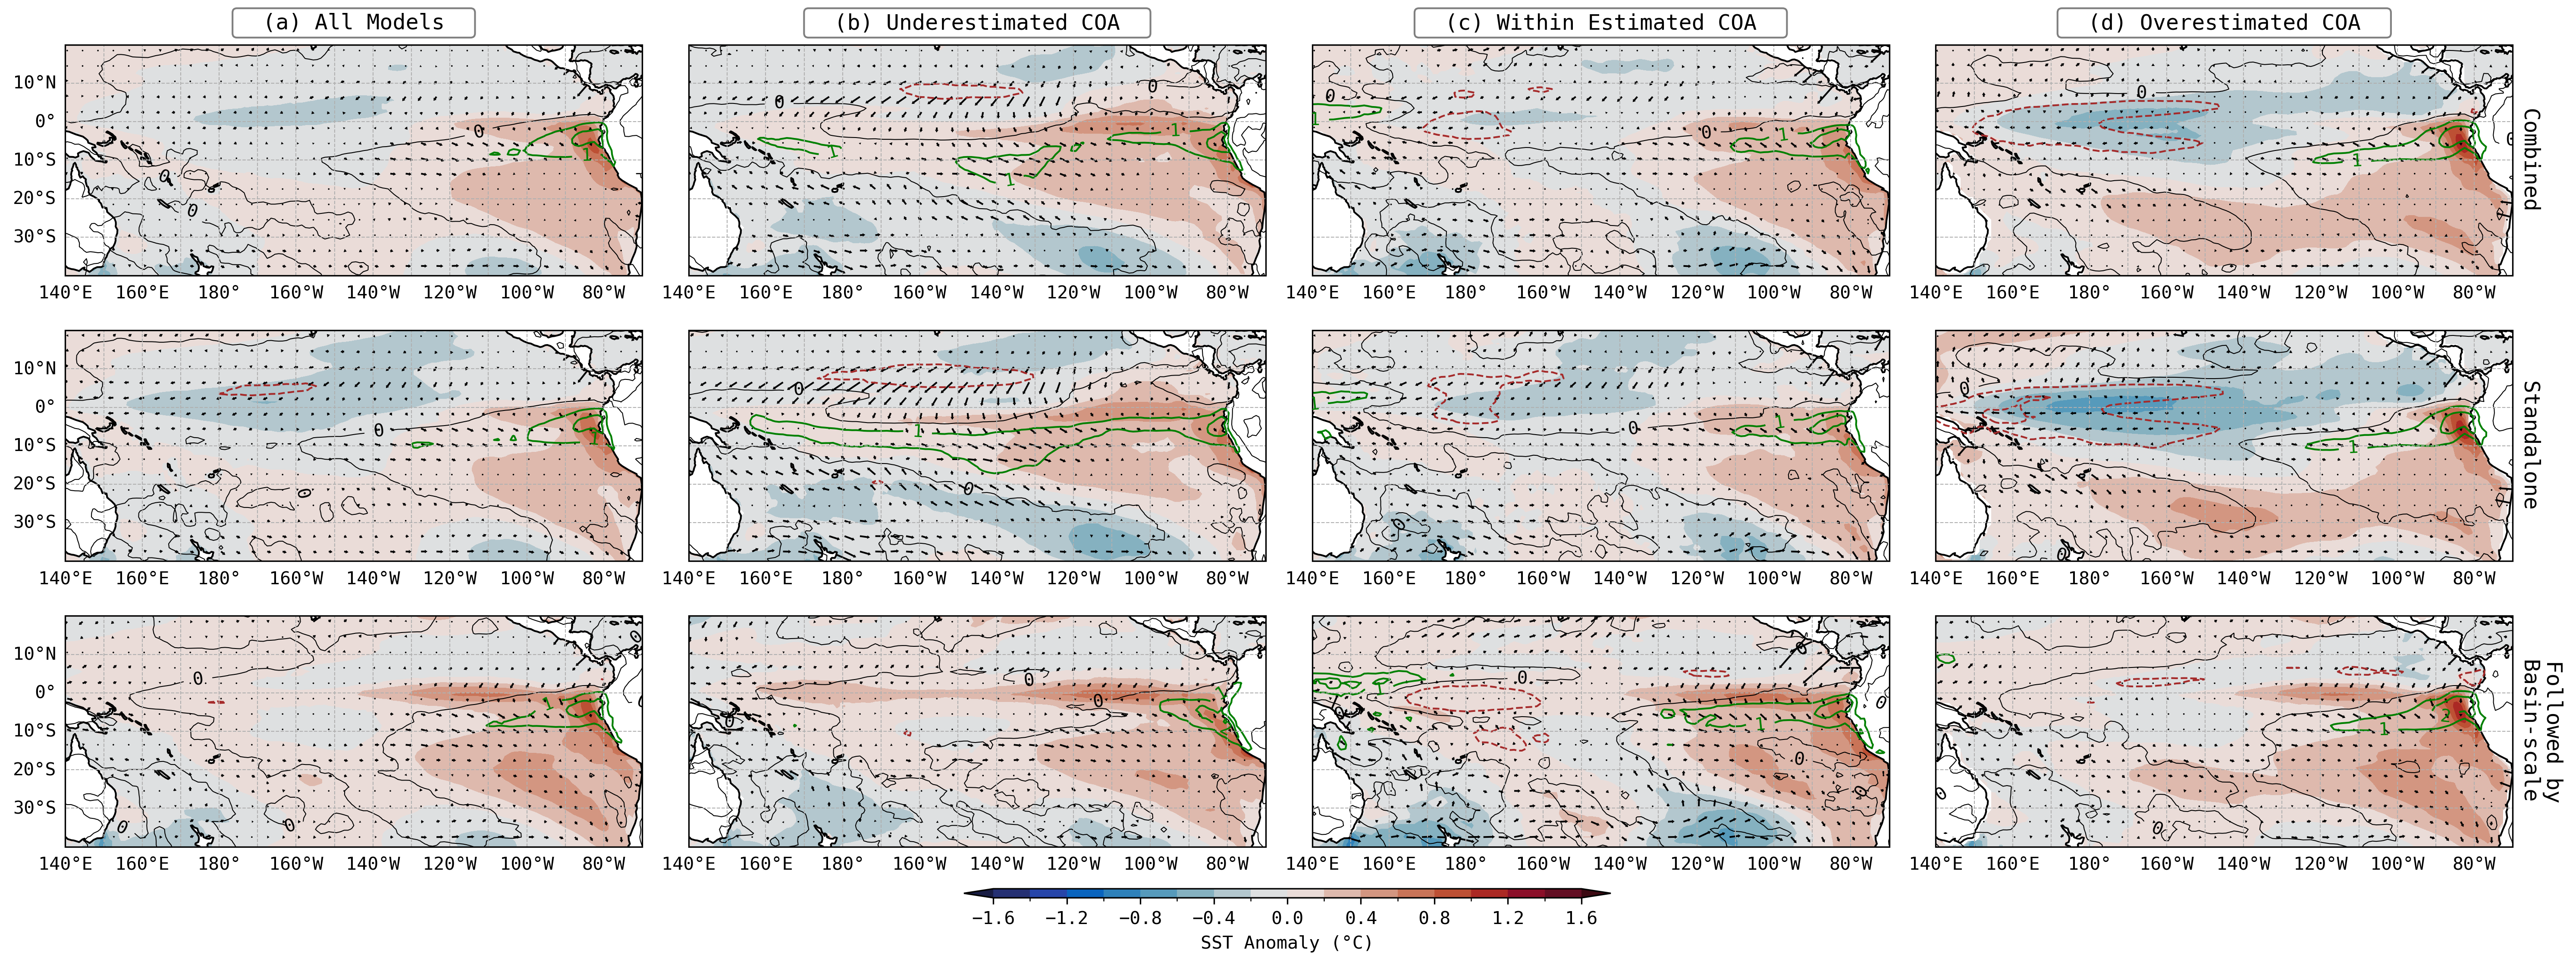

In [ ]:
fig, axs = plt.subplots(
    figsize=(20, 7),
    nrows=3,
    ncols=4,
    subplot_kw=dict(projection=ccrs.PlateCarree(central_longitude=180)),
    dpi=300,
)

for _col, (first_var, second_var, third_var, title) in enumerate(
    [
        (combined_coa_composite_mean, combined_coa_standalone_composite_mean, combined_coa_nonstandalone_composite_mean, "(a) All Models"),
        (orange_coa_composite_mean, orange_coa_standalone_composite_mean, orange_coa_nonstandalone_composite_mean, "(b) Underestimated COA"),
        (green_coa_composite_mean, green_coa_standalone_composite_mean, green_coa_nonstandalone_composite_mean, "(c) Within Estimated COA"),
        (red_coa_composite_mean, red_coa_standalone_composite_mean, red_coa_nonstandalone_composite_mean, "(d) Overestimated COA"),
    ]
):

    _axs = axs[:, _col]
    tau_factor = 100

    for num, (
        ax,
        sst_sel_plot,
        prec_sel_plot,
        u_sel_plot,
        v_sel_plot,
        letter,
        suptitle,
    ) in enumerate(
        zip(
            _axs,
            [first_var.tos, second_var.tos, third_var.tos],
            [first_var.pr, second_var.pr, third_var.pr],
            [
                first_var.tauu * tau_factor,
                second_var.tauu * tau_factor,
                third_var.tauu * tau_factor,
            ],
            [
                first_var.tauv * tau_factor,
                second_var.tauv * tau_factor,
                third_var.tauv * tau_factor,
            ],
            ["b", "d", "f"],
            ["Combined", "Standalone", "Followed by\nBasin-scale"],
        )
    ):

        _lat = u_sel_plot.lat.data
        _lon = u_sel_plot.lon.data

        prec_sel_plot = prec_sel_plot * 86400
        sst_plot = sst_sel_plot.plot.contourf(
            ax=ax,
            transform=ccrs.PlateCarree(),
            vmax=1.6,
            cmap=cmo.cm.balance,
            levels=17,
            add_colorbar=False,
            extend="both",
        )

        conts = (prec_sel_plot).plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=np.arange(0, 10, 1)[1:],
            colors="g",
            linewidths=1,
        )

        (prec_sel_plot).plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=np.arange(-20, 0, 1),
            colors="brown",
            linewidths=1,
        )

        zero_cont = (prec_sel_plot).plot.contour(
            ax=ax,
            transform=ccrs.PlateCarree(),
            levels=[0],
            colors="k",
            linewidths=0.5,
        )

        nskip = 4
        q = ax.quiver(
            _lon[::nskip].data,
            _lat[::nskip].data,  # Reduce density for clarity
            u_sel_plot.where(u_sel_plot > -8)[::nskip, ::nskip].data,
            v_sel_plot.where(v_sel_plot > -8)[::nskip, ::nskip].data,
            transform=ccrs.PlateCarree(),
            scale=50,  # Adjust arrow size
            width=0.003,
            headlength=1.5,
            headaxislength=1.5,
            headwidth=2,
        )

        ax.clabel(conts, inline_spacing=-2, fmt="%1.0f")
        ax.clabel(zero_cont, inline_spacing=-2, fmt="%1.0f")

        gls = ax.gridlines(
            draw_labels=True, xlocs=np.arange(-180, 180, 10), ls="--", lw=0.5
        )
        gls.top_labels = False
        gls.right_labels = False

        if _col == 0:
            gls.left_labels = True
        else:
            gls.left_labels = False

        ax.add_feature(cfeature.LAND, facecolor="white", zorder=1, edgecolor="k")
        ax.set_extent([140, 290, -40, 20], crs=ccrs.PlateCarree())
        if num == 0:
            ax.text(
                0.5,
                1.05,
                " " * 2 + title + " " * 2,
                transform=ax.transAxes,
                va="bottom",
                ha="center",
                fontsize=12,
                bbox=dict(facecolor="white", edgecolor="grey", boxstyle="round,pad=0.2"),
            )
        if _col == 3:
            ax.text(
                1.01,
                0.5,
                suptitle,
                transform=ax.transAxes,
                va="center",
                ha="left",
                rotation=-90,
                fontsize=12,
                bbox=dict(facecolor="white", edgecolor="none", boxstyle="round,pad=0.2"),
            )


cax = fig.add_axes([0.375, -0.001, 0.25, 0.01])  # [left, bottom, width, height]
cbar = fig.colorbar(sst_plot, cax=cax, orientation="horizontal")
cbar.set_label(r"SST Anomaly (°C)")

fig.tight_layout()